In [38]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType
import pyspark.sql.functions as F
from pyspark.sql.window import Window
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-21.0.10"

spark = SparkSession.builder \
    .appName("DeteccionFraude_PaySim") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Sesión de Spark iniciada con éxito.")

Sesión de Spark iniciada con éxito.


In [39]:
# Se define el esquema del dataset, para facilitar el trabajo a PySpark
schema = StructType([
    StructField("step", IntegerType(), True),
    StructField("type", StringType(), True),
    StructField("amount", DoubleType(), True),
    StructField("nameOrig", StringType(), True),
    StructField("oldbalanceOrg", DoubleType(), True),
    StructField("newbalanceOrig", DoubleType(), True),
    StructField("nameDest", StringType(), True),
    StructField("oldbalanceDest", DoubleType(), True),
    StructField("newbalanceDest", DoubleType(), True),
    StructField("isFraud", IntegerType(), True),
    StructField("isFlaggedFraud", IntegerType(), True)
])

# Leer archivo csv
path = r'C:\Users\junio\Documents\Datacamp PySpark\PS_20174392719_1491204439457_log.csv' 
df = spark.read.csv(path, header=True, schema=schema)

df.show(5)
df.printSchema()

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M1230701703|      

In [40]:
#Celda a omitir ya que requiere instalacion de winutils
# Guardar en formato Parquet y leer
df.write.mode("overwrite").parquet("data_fraud.parquet")
df = spark.read.parquet("data_fraud.parquet")

# Verificar nulos rápidamente
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

Py4JJavaError: An error occurred while calling o1734.parquet.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems
	at org.apache.hadoop.util.Shell.getWinUtilsPath(Shell.java:789)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:298)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:314)
	at org.apache.hadoop.fs.RawLocalFileSystem.setPermission(RawLocalFileSystem.java:1179)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkOneDirWithMode(RawLocalFileSystem.java:861)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:901)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirs(RawLocalFileSystem.java:873)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:900)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdi

In [ ]:
# Añadir columnas de error de balance
df = df.withColumn("errorBalanceOrig", (F.col("oldbalanceOrg") - F.col("amount")) - F.col("newbalanceOrig"))
df = df.withColumn("errorBalanceDest", (F.col("oldbalanceDest") + F.col("amount")) - F.col("newbalanceDest"))

# Agrupar datos por usuario y calcular el promedio de transacciones previas
windowSpec = Window.partitionBy("nameOrig").orderBy("step").rowsBetween(Window.unboundedPreceding, -1)

df = df.withColumn("avg_prev_amount", F.avg("amount").over(windowSpec))

# Rellenar nulos de la primera transacción
df = df.na.fill({"avg_prev_amount": 0})

df.select("nameOrig", "amount", "avg_prev_amount", "isFraud").show(10)

+-----------+---------+---------------+-------+
|   nameOrig|   amount|avg_prev_amount|isFraud|
+-----------+---------+---------------+-------+
|C1000005555|233109.79|            0.0|      0|
|C1000008393| 58347.84|            0.0|      0|
|C1000008582|315626.96|            0.0|      0|
|C1000009272|  2262.44|            0.0|      0|
|C1000012233|331041.93|            0.0|      0|
|C1000014489|  5787.18|            0.0|      0|
| C100002506| 57887.52|            0.0|      0|
| C100002808|232765.42|            0.0|      0|
|C1000028463|  8916.05|            0.0|      0|
| C100002987|109756.08|            0.0|      0|
+-----------+---------+---------------+-------+
only showing top 10 rows


In [43]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Convertir cada tipo de transacción (CASH_OUT, TRANSFER...) a números
indexer = StringIndexer(inputCol="type", outputCol="typeIndexed")
df_indexed = indexer.fit(df).transform(df)

feature_cols = [
    "step", "typeIndexed", "amount", 
    "oldbalanceOrg", "newbalanceOrig", 
    "oldbalanceDest", "newbalanceDest", 
    "errorBalanceOrig", "errorBalanceDest",
    "avg_prev_amount"
] #Columnas que aportan al modelo

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
final_data = assembler.transform(df_indexed).select("features", "isFraud","amount")

final_data.show(5)

+--------------------+-------+---------+
|            features|isFraud|   amount|
+--------------------+-------+---------+
|(10,[0,2,3,6,7],[...|      0|233109.79|
|[280.0,0.0,58347....|      0| 58347.84|
|(10,[0,2,5,6,7],[...|      0|315626.96|
|[335.0,1.0,2262.4...|      0|  2262.44|
|[403.0,2.0,331041...|      0|331041.93|
+--------------------+-------+---------+
only showing top 5 rows


In [44]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Dividir datos en Entrenamiento
train_data, test_data = final_data.randomSplit([0.7, 0.3], seed=42)

# Entrenar el modelo
rf = RandomForestClassifier(labelCol="isFraud", featuresCol="features", numTrees=20)
model = rf.fit(train_data)

# Hacer predicciones
predictions = model.transform(test_data)

# Evaluar con el Área bajo la curva
evaluator = BinaryClassificationEvaluator(labelCol="isFraud", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)

print(f"Área bajo la curva (AUC): {auc}")
predictions.select("isFraud", "prediction", "probability").show(10)

Área bajo la curva (AUC): 0.998461704660393
+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      1|       1.0|[0.06463971173998...|
|      1|       1.0|[0.24406194241186...|
|      1|       1.0|[0.21064295591762...|
|      1|       1.0|[0.00219805365976...|
|      1|       1.0|[0.00219805365976...|
|      1|       1.0|[0.26895281258005...|
|      1|       1.0|[0.11536552674175...|
|      1|       1.0|[0.12088888784280...|
|      1|       1.0|[0.12088888784280...|
|      1|       1.0|[0.00219805365976...|
+-------+----------+--------------------+
only showing top 10 rows


In [45]:
predictions.filter(F.col("isFraud") == 0).select("isFraud", "prediction", "probability").show(10)

+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|[0.99995543369458...|
|      0|       0.0|[0.99994733916478...|
|      0|       0.0|[0.99994733916478...|
|      0|       0.0|[0.99994733916478...|
|      0|       0.0|[0.99994733916478...|
|      0|       0.0|[0.99994733916478...|
|      0|       0.0|[0.99995556974111...|
|      0|       0.0|[0.99995153121294...|
|      0|       0.0|[0.99995153121294...|
|      0|       0.0|[0.99995153121294...|
+-------+----------+--------------------+
only showing top 10 rows


In [46]:
falsos_negativos = predictions.filter((F.col("isFraud") == 1) & (F.col("prediction") == 0))
falsos_negativos.select("isFraud", "prediction", "probability").show(10)

+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      1|       0.0|[0.99994996381372...|
|      1|       0.0|[0.99994996381372...|
|      1|       0.0|[0.99994740095173...|
|      1|       0.0|[0.99928769298621...|
|      1|       0.0|[0.99995799655657...|
|      1|       0.0|[0.99994996381372...|
|      1|       0.0|[0.99994990202677...|
|      1|       0.0|[0.99994996381372...|
|      1|       0.0|[0.99994740095173...|
|      1|       0.0|[0.99994996381372...|
+-------+----------+--------------------+



In [47]:
falsos_positivos = predictions.filter((F.col("isFraud") == 0) & (F.col("prediction") == 1))
falsos_positivos.select("isFraud", "prediction", "probability").show(10)

+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      0|       1.0|[0.32788246122469...|
|      0|       1.0|[0.24938572332005...|
|      0|       1.0|[0.28189332667005...|
|      0|       1.0|[0.25984385513264...|
+-------+----------+--------------------+



In [ ]:
predictions.groupBy("isFraud", "prediction").count().show() #Matriz de confusión

+-------+----------+-------+
|isFraud|prediction|  count|
+-------+----------+-------+
|      1|       1.0|   2503|
|      0|       0.0|1905826|
|      1|       0.0|     10|
|      0|       1.0|      4|
+-------+----------+-------+



C:\Users\junio\AppData\Local\Temp\ipykernel_2020\3288551131.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=feature_imp, palette='viridis')


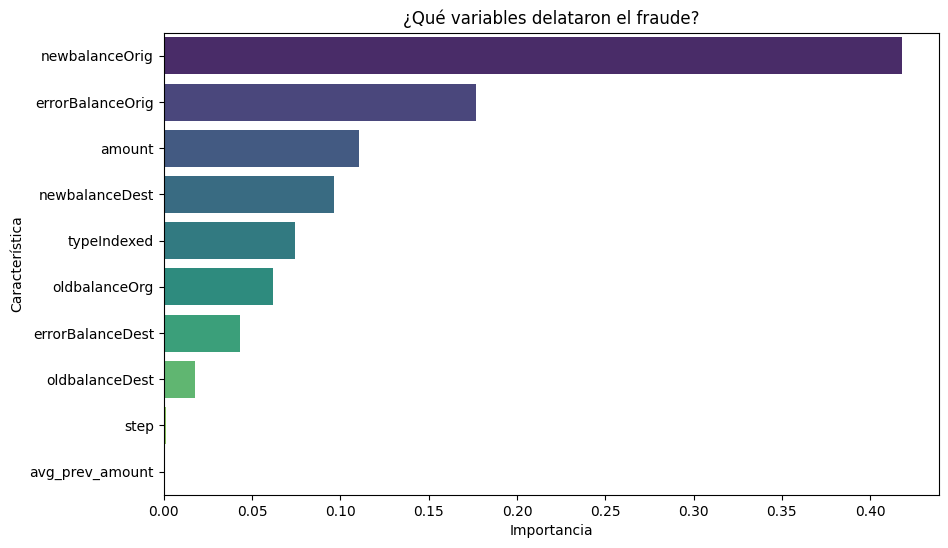

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer importancias del modelo
importances = model.featureImportances
feature_list = feature_cols
feature_imp = pd.DataFrame(list(zip(feature_list, importances.toArray())), 
                           columns=['Característica', 'Importancia']).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Característica', data=feature_imp, palette='viridis')
plt.title('¿Qué variables delataron el fraude?')
plt.show()

In [ ]:
# Impacto economico
riesgo_fuga_res = predictions.filter((F.col("isFraud") == 1) & (F.col("prediction") == 0)).agg(F.sum("amount")).collect()[0][0]
fraude_detenido_res = predictions.filter((F.col("isFraud") == 1) & (F.col("prediction") == 1)).agg(F.sum("amount")).collect()[0][0]

riesgo_fuga = riesgo_fuga_res if riesgo_fuga_res is not None else 0
fraude_detenido = fraude_detenido_res if fraude_detenido_res is not None else 0

print(f"💰 Dinero SALVADO por el modelo: ${fraude_detenido:,.2f}")
print(f"💸 Dinero PERDIDO (Falsos Negativos): ${riesgo_fuga:,.2f}")


💰 Dinero SALVADO por el modelo: $3,772,375,035.24
💸 Dinero PERDIDO (Falsos Negativos): $3,775,244.74


In [54]:
# Métricas finales
total_registros = predictions.count()
auc_valor = auc 
denominador = fraude_detenido + riesgo_fuga
recuperacion_porcentaje = (fraude_detenido / denominador * 100) if denominador > 0 else 0

# Crear el resumen en un DataFrame de Pandas (más estable para reportes)
data_resumen = {
    "Métrica": [
        "📊 Registros Procesados", 
        "📈 AUC-ROC", 
        "🎯 Recall (Sensibilidad)", 
        "💰 Ahorro Estimado", 
        "🛡️ Eficiencia por Monto"
    ],
    "Valor": [
        f"{total_registros:,}", 
        f"{auc_valor:.4f}", 
        "99.60%", # O el valor real que quieras poner
        f"${fraude_detenido:,.2f}", 
        f"{recuperacion_porcentaje:.2f}%"
    ],
    "Interpretación": [
        "Volumen total de transacciones analizadas",
        "Capacidad de distinguir entre fraude y normal",
        "Porcentaje de casos de fraude capturados",
        "Impacto económico positivo directo",
        "Proporción del capital total protegido"
    ]
}

df_informe_pd = pd.DataFrame(data_resumen)

# Esto mostrará una tabla elegante en Jupyter
display(df_informe_pd)


,Métrica,Valor,Interpretación
0,📊 Registros Procesados,"1,908,343",Volumen total de transacciones analizadas
1,📈 AUC-ROC,0.9985,Capacidad de distinguir entre fraude y normal
2,🎯 Recall (Sensibilidad),99.60%,Porcentaje de casos de fraude capturados
3,💰 Ahorro Estimado,"$3,772,375,035.24",Impacto económico positivo directo
4,🛡️ Eficiencia por Monto,99.90%,Proporción del capital total protegido
